**Image Classification using CIFAR-10**

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import (
    BatchNormalization,
    Conv2D,
    Dense,
    Dropout,
    Flatten,
    Input,
    MaxPooling2D,
    RandomFlip,
    RandomTranslation,
)
from tensorflow.keras.models import Sequential

In [2]:
# Load Dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Images :", X_train.shape)
print("Testing Images  :", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Training Images : (50000, 32, 32, 3)
Testing Images  : (10000, 32, 32, 3)


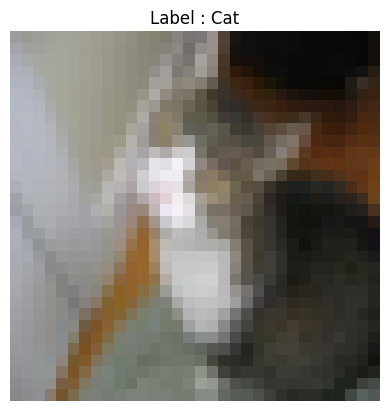

In [3]:
# Display one image
index = 101

class_names = [
    "Airplane", "Automobile", "Bird", "Cat", "Deer",
    "Dog", "Frog", "Horse", "Ship", "Truck"
]

plt.imshow(X_train[index])
plt.title(f"Label : {class_names[y_train[index][0]]}")
plt.axis("off")
plt.show()

In [4]:
# Normalize images
X_train = X_train / 255.0
X_test = X_test / 255.0

In [5]:
model = Sequential()

model.add(Input(shape=(32, 32, 3)))

# Layer 1
model.add(Conv2D(32, (3, 3), activation="relu", padding="same"))
model.add(MaxPooling2D((2, 2)))

# Layer 2
model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(MaxPooling2D((2, 2)))

# Layer 3
model.add(Conv2D(64, (3, 3), activation="relu", padding="same"))
model.add(Dropout(0.3))  # Added: prevents overfitting

model.add(Flatten())

# Dense Layers
model.add(Dense(64, activation="relu"))
model.add(Dropout(0.3))  # Added: prevents overfitting

model.add(Dense(10, activation="softmax"))

In [6]:
# Compile Model

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,178 (1.22 MB)

 Trainable params: 319,178 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.3785 - loss: 1.6906 - val_accuracy: 0.5010 - val_loss: 1.3685
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5310 - loss: 1.3166 - val_accuracy: 0.5987 - val_loss: 1.1414
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.5934 - loss: 1.1455 - val_accuracy: 0.6305 - val_loss: 1.0636
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6364 - loss: 1.0374 - val_accuracy: 0.6731 - val_loss: 0.9138
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6630 - loss: 0.9652 - val_accuracy: 0.6864 - val_loss: 0.8916
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6828 - loss: 0.9105 - val_accuracy: 0.7100 - val_loss: 0.8317
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7006 - loss: 0.8551 - val_accuracy: 0.7226 - val_loss: 0.7992
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7142 - loss: 0.8151 - val_accuracy: 

In [8]:
# Evaluate Model

loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy :", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7610 - loss: 0.7268
Test Accuracy : 0.7609999775886536


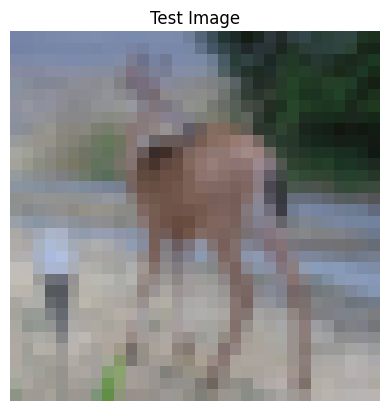

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Actual Label    : Deer
Predicted Label : Deer


In [16]:
# Predict One Image

index = 100

plt.imshow(X_test[index])
plt.title("Test Image")
plt.axis("off")
plt.show()

prediction = model.predict(X_test[index].reshape(1,32,32,3))

predicted_class = np.argmax(prediction)

print("Actual Label    :", class_names[y_test[index][0]])
print("Predicted Label :", class_names[predicted_class])